# EDA 통합: 데이터 확인 주제별 분석

아래 주제들을 **한 노트북에서 순서대로** 확인할 수 있도록 구성했습니다.
- 각 섹션에 **코드 흐름 주석**과 **해석·결론**을 넣었습니다.

**주제 목록**  
0. 전체 기간 일별 매출액·유입 유저 수 (데이터 커버리지 확인)  
1. Olist 판매 제품 카테고리 키워드 추출  
2. 브라질 검색량 트렌드(시장 변화)  
3. 시장 변화 vs Olist 카테고리 실제 변화 비교(수치)  
4. 월별 최다 판매 카테고리 + 세부 상품 TOP 5  
5. 함께 많이 판매된 카테고리 (4050 여성 데이터 한계 안내)  
6. 카테고리별 재구매 주기  
7. 리뷰·배송 기간·만족도가 재구매에 미친 영향  


---
## 공통: 데이터 로드

**흐름**: data/ 존재 여부 확인 → 없으면 kagglehub에서 직접 로드 → delivered 주문만 사용, 날짜/카테고리 전처리.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from itertools import combinations

# 1) 데이터 경로: data/ 또는 kagglehub
DATA_DIR = Path.cwd() / "data"
for _ in [Path.cwd() / "data", Path.cwd().parent / "예측 대시보드 용 프로젝트" / "data"]:
    if (_ / "orders_delivered.csv").exists():
        DATA_DIR = _
        break

if not (DATA_DIR / "orders_delivered.csv").exists():
    import kagglehub
    _path = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
    orders = pd.read_csv(_path / "olist_orders_dataset.csv")
    orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")
    orders = orders[orders["order_status"] == "delivered"].copy()
    order_items = pd.read_csv(_path / "olist_order_items_dataset.csv")
    products = pd.read_csv(_path / "olist_products_dataset.csv")
    customers = pd.read_csv(_path / "olist_customers_dataset.csv")
    order_reviews = pd.read_csv(_path / "olist_order_reviews_dataset.csv")
    order_payments = pd.read_csv(_path / "olist_order_payments_dataset.csv")
    products["product_category_name"] = products["product_category_name"].fillna("unknown")
    order_payments["payment_type"] = order_payments["payment_type"].replace("not_defined", "unknown")
    print("(data/ 없음 → kagglehub에서 로드)")
else:
    orders = pd.read_csv(DATA_DIR / "orders_delivered.csv")
    order_items = pd.read_csv(DATA_DIR / "order_items.csv")
    products = pd.read_csv(DATA_DIR / "products.csv")
    customers = pd.read_csv(DATA_DIR / "customers.csv")
    order_reviews = pd.read_csv(DATA_DIR / "order_reviews.csv")
    order_payments = pd.read_csv(DATA_DIR / "order_payments.csv")
    orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"], errors="coerce")

# 2) 주문-상품-카테고리 결합 (전체 EDA에서 공통 사용)
products["product_category_name"] = products["product_category_name"].fillna("unknown")
ord = order_items.merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
ord["product_category_name"] = ord["product_category_name"].fillna("unknown")
ord = ord.merge(orders[["order_id", "order_purchase_timestamp", "customer_id"]], on="order_id")
ord = ord.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
ord["order_month"] = ord["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

print("orders:", orders.shape, "| ord(주문-상품):", ord.shape)

orders: (96478, 8) | ord(주문-상품): (110197, 12)


---
## 0. 전체 기간 일별 매출·유입 유저 (데이터 커버리지 확인)

**"2016년 데이터가 10월만 있다"는 뜻**: Olist **공개 데이터셋**에 포함된 **배송 완료(delivered) 주문**이 2016년에는 **10월에만** 몰려 있다는 의미입니다.  
(실제 Olist가 2016년에 10월만 영업한 것이 아니라, 캐글/Kaggle에 공개된 샘플이 그렇게 수집·제공된 것입니다.)  
- **2016**: 10월 265건 + 9월 1건, 12월 1건 수준 → 실질적으로 **10월만** 시계열로 의미 있음  
- **2017**: 1~12월 전부 존재  
- **2018**: 1~8월만 존재 (9월 이후 없음)

아래 그래프로 **일별 매출액**과 **일별 유입 유저 수**(그날 처음 구매한 고객 수)를 보면, 전체 기간 데이터가 어디에 있는지 한눈에 확인할 수 있습니다.

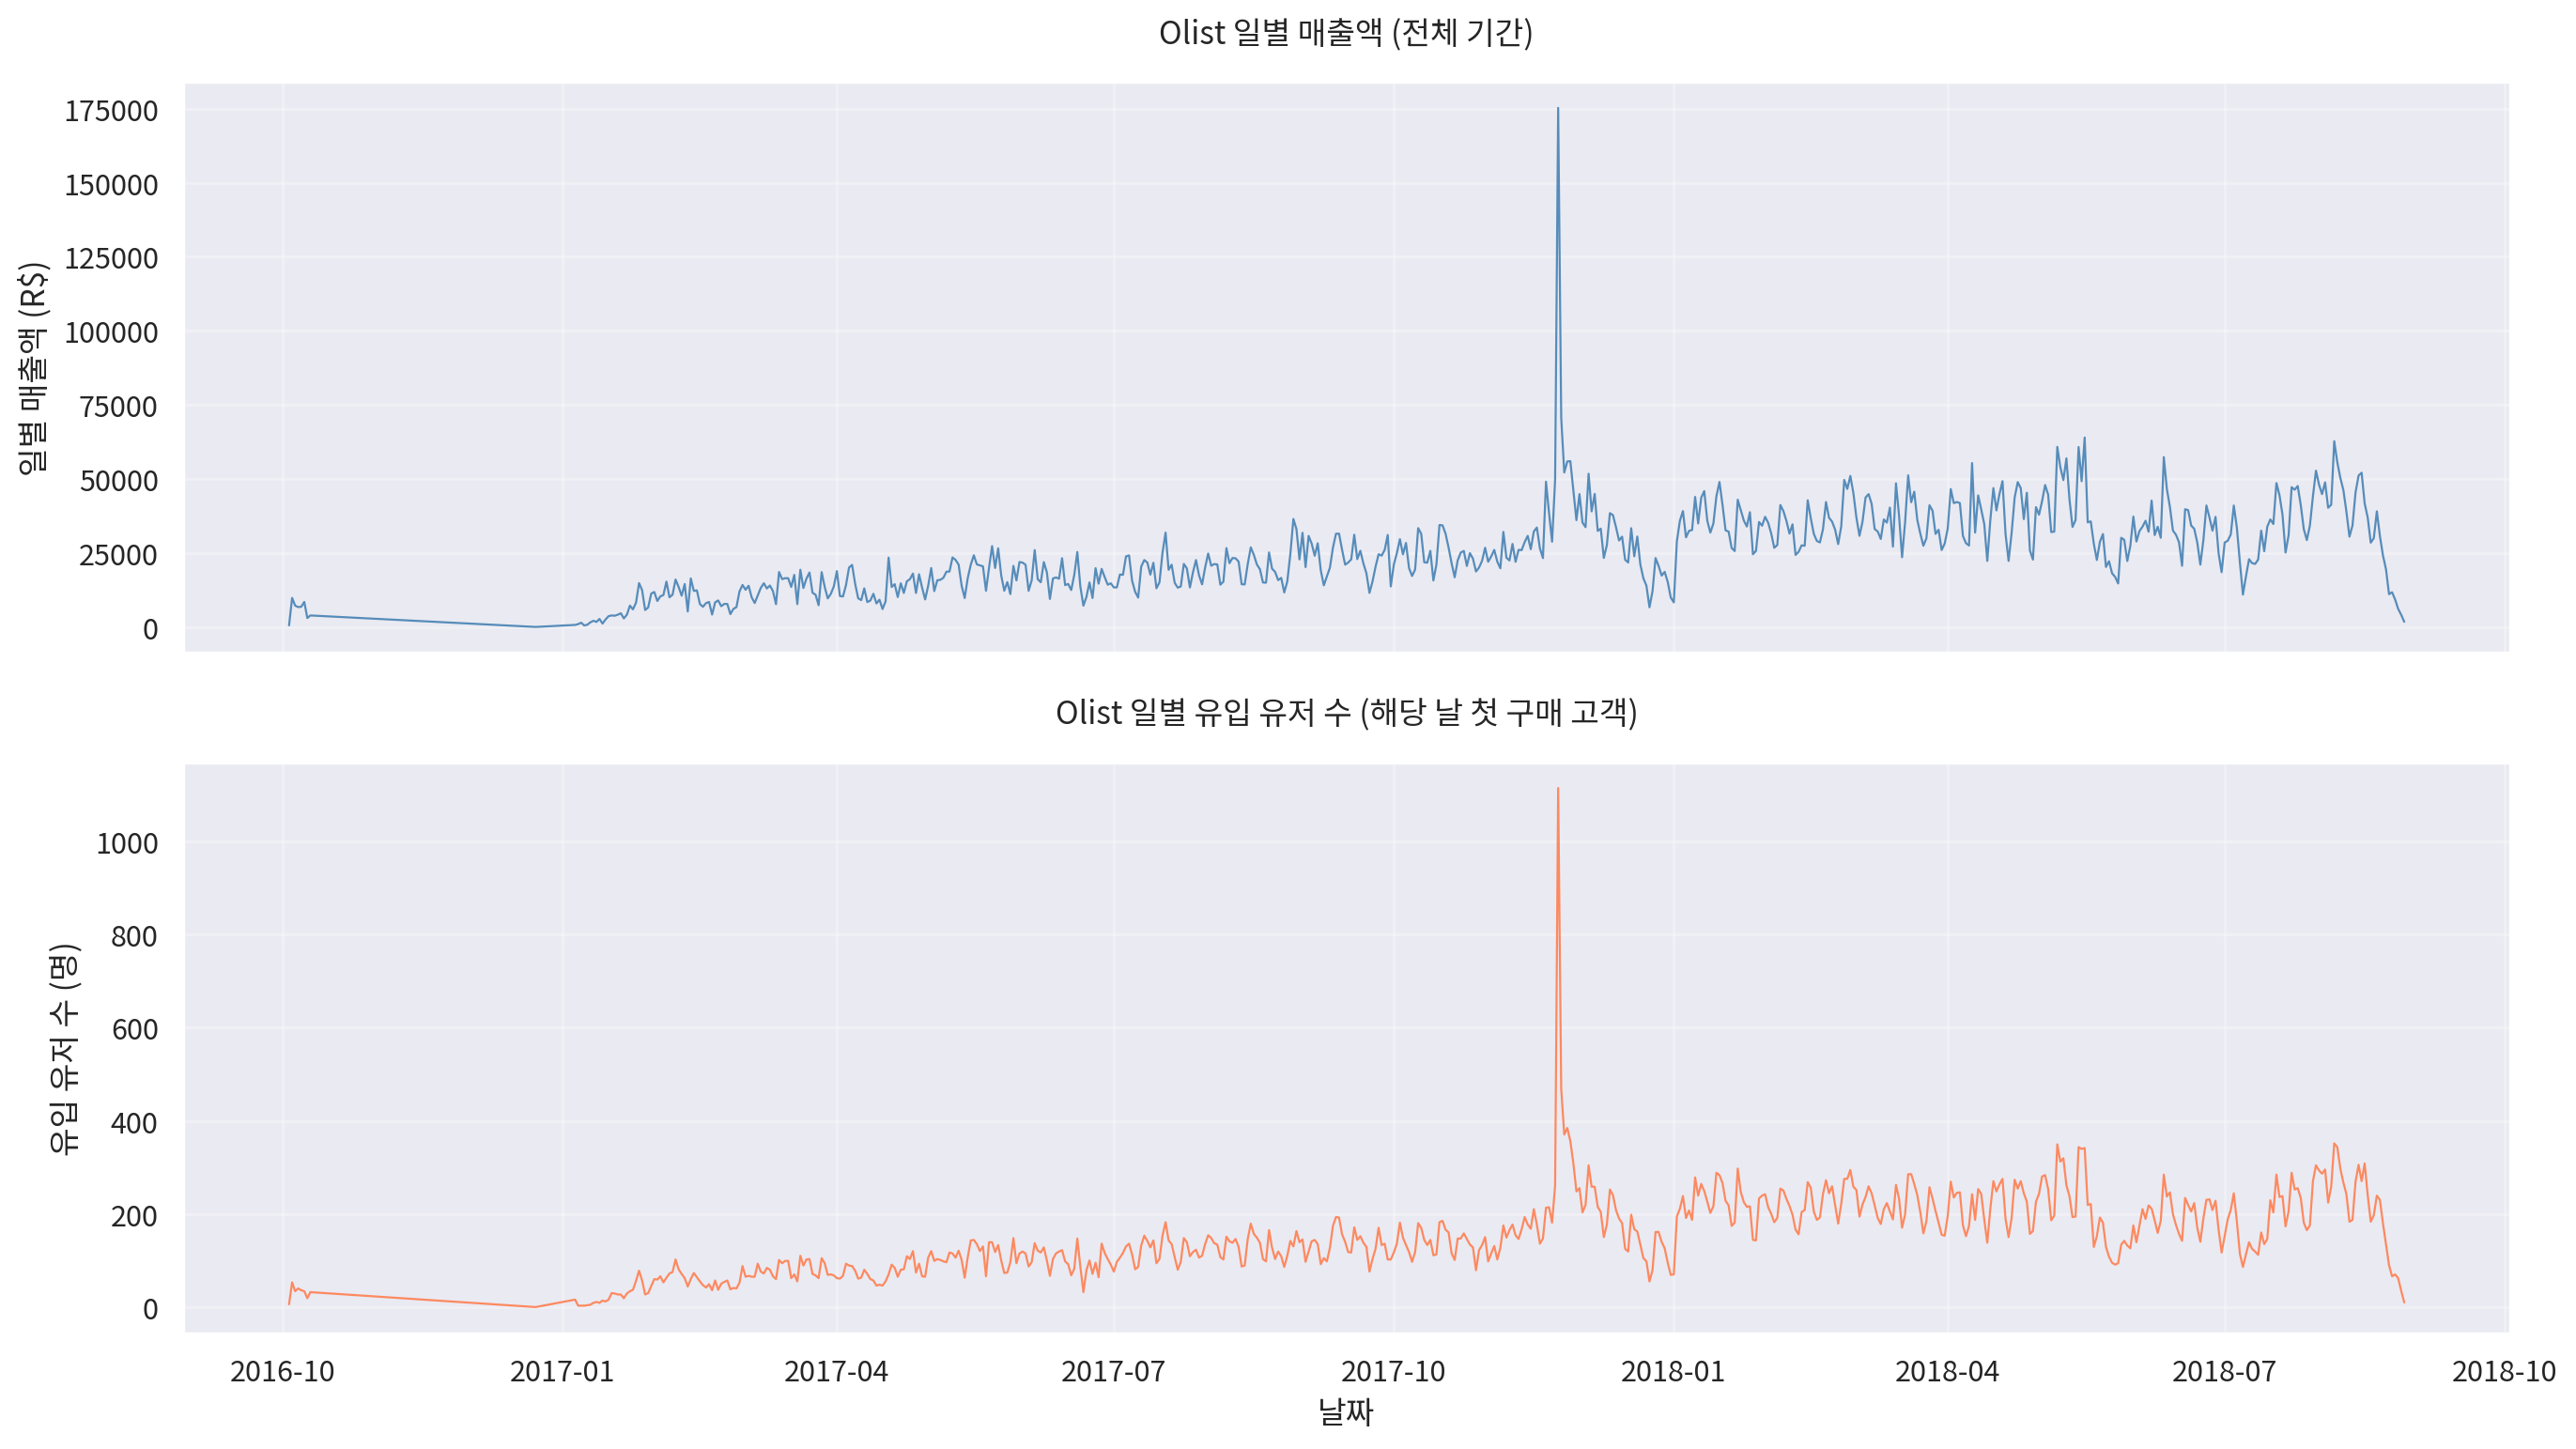

연도·월별 주문 수·매출 (데이터 존재 구간 확인):
 year  month  주문수          매출
 2016     10  265   46566.710
 2016     12    1      19.620
 2017      1  750  127545.670
 2017      2 1653  271298.650
 2017      3 2546  414369.390
 2017      4 2303  390952.180
 2017      5 3546  567066.730
 2017      6 3135  490225.600
 2017      7 3872  566403.930
 2017      8 4193  646000.610
 2017      9 4150  701169.990
 2017     10 4478  751140.270
 2017     11 7289 1153528.050
 2017     12 5513  843199.170
 2018      1 7069 1078606.860
 2018      2 6555  966510.880
 2018      3 7003 1120678.000
 2018      4 6798 1132933.950
 2018      5 6749 1128836.690
 2018      6 6099 1012090.680
 2018      7 6159 1027903.860
 2018      8 6351  985414.280


In [2]:
# 주문별 결제액 (order_payments 합산)
order_value = order_payments.groupby("order_id")["payment_value"].sum().reset_index(name="order_value")
orders_with_val = orders.merge(order_value, on="order_id")
orders_with_val = orders_with_val.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
orders_with_val["order_date"] = orders_with_val["order_purchase_timestamp"].dt.date

# 일별 매출액
daily_revenue = orders_with_val.groupby("order_date")["order_value"].sum().reset_index()
daily_revenue["order_date"] = pd.to_datetime(daily_revenue["order_date"])

# 일별 유입 유저 수 = 그날 처음 구매한 고객 수 (첫 주문일이 해당 날인 고객)
first_order = orders_with_val.groupby("customer_unique_id")["order_purchase_timestamp"].min().reset_index()
first_order["first_date"] = first_order["order_purchase_timestamp"].dt.date
daily_new_users = first_order.groupby("first_date").size().reset_index(name="new_users")
daily_new_users["first_date"] = pd.to_datetime(daily_new_users["first_date"])

# 그래프: 전체 기간 일별 매출 + 일별 유입 유저
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(daily_revenue["order_date"], daily_revenue["order_value"], color="steelblue", linewidth=0.8, alpha=0.9)
ax1.set_ylabel("일별 매출액 (R$)")
ax1.set_title("Olist 일별 매출액 (전체 기간)")
ax1.grid(True, alpha=0.3)
ax2.plot(daily_new_users["first_date"], daily_new_users["new_users"], color="coral", linewidth=0.8, alpha=0.9)
ax2.set_ylabel("유입 유저 수 (명)")
ax2.set_xlabel("날짜")
ax2.set_title("Olist 일별 유입 유저 수 (해당 날 첫 구매 고객)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 연도·월별 요약 (데이터 커버리지 확인)
orders_with_val["year"] = orders_with_val["order_purchase_timestamp"].dt.year
orders_with_val["month"] = orders_with_val["order_purchase_timestamp"].dt.month
coverage = orders_with_val.groupby(["year", "month"]).agg(주문수=("order_id", "nunique"), 매출=("order_value", "sum")).reset_index()
print("연도·월별 주문 수·매출 (데이터 존재 구간 확인):")
print(coverage.to_string(index=False))

---
## 1. Olist 판매 제품 카테고리 키워드 추출

**목적**: Google Trends 등에서 검색량 분석할 때 쓸 **키워드 목록**을 Olist 실제 판매 카테고리에서 뽑기.  
**흐름**: 주문-상품-카테고리 집계 → 판매량 상위 정렬 → 카테고리명을 키워드로 변환(언더스코어→공백) → **영어 번역**은 Olist 공식 `product_category_name_translation` 테이블로 병합해 `keyword`(포르투갈어), `keyword_english`(영어) 컬럼으로 함께 표시.

In [3]:
# 주문 건수 기준 카테고리별 판매량 (order_items 행 기준 = 주문당 상품 수)
cat_vol = ord.groupby("product_category_name").agg(
    order_item_count=("order_id", "count"),
    order_count=("order_id", "nunique"),
).reset_index().sort_values("order_item_count", ascending=False)

# 키워드: 카테고리명 언더스코어 → 공백 (포르투갈어 검색어)
cat_vol["keyword"] = cat_vol["product_category_name"].str.replace("_", " ")

# 영어 번역: Olist 공식 번역 테이블 로드 (data/ 또는 kagglehub)
category_translation = pd.DataFrame()
for _path in [DATA_DIR / "category_translation.csv", Path.cwd() / "category_translation.csv"]:
    if _path.exists():
        category_translation = pd.read_csv(_path, encoding="utf-8-sig")
        break
if category_translation.empty:
    try:
        import kagglehub
        _kpath = Path(kagglehub.dataset_download("olistbr/brazilian-ecommerce"))
        category_translation = pd.read_csv(_kpath / "product_category_name_translation.csv", encoding="utf-8-sig")
    except Exception:
        pass
if not category_translation.empty and "product_category_name_english" in category_translation.columns:
    cat_vol = cat_vol.merge(category_translation[["product_category_name", "product_category_name_english"]], on="product_category_name", how="left")
    cat_vol["keyword_english"] = cat_vol["product_category_name_english"].fillna(cat_vol["product_category_name"]).astype(str).str.replace("_", " ")
else:
    cat_vol["keyword_english"] = ""

keywords_olist = cat_vol["keyword"].tolist()

print("Olist 판매 제품 카테고리 키워드 (판매량 상위 20개) — 포르투갈어 + 영어:")
display_cols = ["product_category_name", "order_item_count", "order_count", "keyword", "keyword_english"]
print(cat_vol[[c for c in display_cols if c in cat_vol.columns]].head(20).to_string(index=False))
print("\n키워드 리스트(상위 15개, Trends 등에 사용):", keywords_olist[:15])

Olist 판매 제품 카테고리 키워드 (판매량 상위 20개) — 포르투갈어 + 영어:
      product_category_name  order_item_count  order_count                     keyword          keyword_english
            cama_mesa_banho             10953         9272             cama mesa banho           bed bath table
               beleza_saude              9465         8647                beleza saude            health beauty
              esporte_lazer              8431         7530               esporte lazer           sports leisure
           moveis_decoracao              8160         6307            moveis decoracao          furniture decor
     informatica_acessorios              7644         6530      informatica acessorios    computers accessories
      utilidades_domesticas              6795         5743       utilidades domesticas               housewares
         relogios_presentes              5859         5495          relogios presentes            watches gifts
                  telefonia              4430         40

**결론 (1)**  
- Olist에서 실제로 많이 판매된 **카테고리명**을 그대로 검색 키워드 후보로 쓸 수 있다.  
- 상위 키워드는 주로 `cama mesa banho`, `beleza saude`, `esporte lazer` 등 일상·생활용품·뷰티·스포츠 계열이다.  
- 이 키워드 리스트를 02번 노트북(Google Trends)에 넣어 브라질 검색량을 수집하면 된다.

---
## 2. 브라질 검색량 트렌드 (시장 변화)

**목적**: 위에서 뽑은 키워드의 **브라질(geo=BR) 검색량** 트렌드로 "시장 관심도" 변화 파악.  
**흐름**: 02번 노트북에서 저장한 CSV가 있으면 로드 → 없으면 파일 경로 안내 및 수동 실행 안내.

In [4]:
# Google Trends 결과 CSV 경로 (02-Google_Trends_BR_2016-2018.ipynb 실행 후 생성)
TRENDS_CSV = Path.cwd() / "google_trends_br_2016_2018_olist.csv"
for _ in [Path.cwd(), Path.cwd().parent / "예측 대시보드 용 프로젝트"]:
    if (_ / "google_trends_br_2016_2018_olist.csv").exists():
        TRENDS_CSV = _ / "google_trends_br_2016_2018_olist.csv"
        break

if TRENDS_CSV.exists():
    trends = pd.read_csv(TRENDS_CSV)
    trends["date"] = pd.to_datetime(trends["date"], errors="coerce")
    print("검색량 트렌드 데이터:")
    print(trends.head(10))
    print("\n키워드 수:", trends["keyword"].nunique() if "keyword" in trends.columns else "컬럼 확인 필요")
else:
    print("Google Trends CSV 없음. 02-Google_Trends_BR_2016-2018.ipynb 를 실행해 google_trends_br_2016_2018_olist.csv 를 생성한 뒤 다시 실행하세요.")
    trends = pd.DataFrame()

검색량 트렌드 데이터:
        date     keyword  interest
0 2015-12-27  perfumaria         9
1 2016-01-03  perfumaria         9
2 2016-01-10  perfumaria        10
3 2016-01-17  perfumaria        11
4 2016-01-24  perfumaria        10
5 2016-01-31  perfumaria        10
6 2016-02-07  perfumaria         9
7 2016-02-14  perfumaria        10
8 2016-02-21  perfumaria         9
9 2016-02-28  perfumaria        10

키워드 수: 73


**결론 (2)**  
- 브라질에서의 **키워드별 검색량 시계열**이 있으면, 시장의 관심도가 "언제 올랐고/내렸는지"를 볼 수 있다.  
- CSV가 준비되어 있으면 아래 3번에서 Olist 실제 매출·판매량과 기간을 맞춰 비교할 수 있다.

---
## 3. 시장 변화 vs Olist 카테고리 실제 변화 (수치)

**목적**: 검색량 트렌드(시장)가 변할 때 **Olist 해당 카테고리 판매**가 실제로 얼마나 +/− 했는지 수치로 확인.  
**흐름**: (1) 기간을 월/분기로 자르기 (2) 카테고리별 Olist 매출·주문 수 전년 대비 또는 구간 대비 변화율 계산 (3) Trends와 기간 맞추어 비교 (가능하면 키워드-카테고리 매칭).

In [5]:
# 3-1) Olist 월별·카테고리별 매출/주문 수
monthly_cat = ord.groupby(["order_month", "product_category_name"]).agg(
    revenue=("price", "sum"),
    order_count=("order_id", "nunique"),
    item_count=("order_id", "count"),
).reset_index()

# 3-2) 전월 대비 변화율 (카테고리별)
monthly_cat = monthly_cat.sort_values(["product_category_name", "order_month"])
monthly_cat["revenue_pct_change"] = monthly_cat.groupby("product_category_name")["revenue"].pct_change() * 100
monthly_cat["order_count_pct_change"] = monthly_cat.groupby("product_category_name")["order_count"].pct_change() * 100

# 3-3) 2017 vs 2018 같은 기간 비교 (예: 1~6월)
monthly_cat["year"] = monthly_cat["order_month"].dt.year
monthly_cat["month_num"] = monthly_cat["order_month"].dt.month
h1_2017 = monthly_cat[(monthly_cat["year"] == 2017) & (monthly_cat["month_num"] <= 6)].groupby("product_category_name").agg(
    revenue_2017=("revenue", "sum"), order_count_2017=("order_count", "sum")
).reset_index()
h1_2018 = monthly_cat[(monthly_cat["year"] == 2018) & (monthly_cat["month_num"] <= 6)].groupby("product_category_name").agg(
    revenue_2018=("revenue", "sum"), order_count_2018=("order_count", "sum")
).reset_index()
compare = h1_2017.merge(h1_2018, on="product_category_name", how="outer").fillna(0)
compare["revenue_change_pct"] = (compare["revenue_2018"] - compare["revenue_2017"]) / (compare["revenue_2017"] + 1) * 100
compare["order_change_pct"] = (compare["order_count_2018"] - compare["order_count_2017"]) / (compare["order_count_2017"] + 1) * 100
compare = compare.sort_values("revenue_change_pct", ascending=False)

print("2018 상반기 vs 2017 상반기 카테고리별 매출·주문 수 변화 (%):")
print(compare.head(15).to_string(index=False))
print("\n변화율이 큰 카테고리 (매출 기준 상위 5):")
print(compare.nlargest(5, "revenue_change_pct")[["product_category_name", "revenue_change_pct", "order_change_pct"]].to_string(index=False))
print("\n변화율이 낮은(또는 마이너스) 카테고리 (하위 5):")
print(compare.nsmallest(5, "revenue_change_pct")[["product_category_name", "revenue_change_pct", "order_change_pct"]].to_string(index=False))

2018 상반기 vs 2017 상반기 카테고리별 매출·주문 수 변화 (%):
                        product_category_name  revenue_2017  order_count_2017  revenue_2018  order_count_2018  revenue_change_pct  order_change_pct
            construcao_ferramentas_iluminacao         0.000             0.000     20441.380           129.000         2044138.000         12900.000
portateis_cozinha_e_preparadores_de_alimentos         0.000             0.000      1958.000             2.000          195800.000           200.000
                            artigos_de_festas         0.000             0.000      1279.000            13.000          127900.000          1300.000
                              fraldas_higiene         0.000             0.000       937.000            17.000           93700.000          1700.000
                                       flores         0.000             0.000       791.550            19.000           79155.000          1900.000
                  portateis_casa_forno_e_cafe        71.900          

**결론 (3)**  
- **2018 상반기 vs 2017 상반기**로 같은 구간을 비교하면, 카테고리별로 **매출·주문 수의 +/− 변화율**을 수치로 볼 수 있다.  
- 상위/하위 5개를 보면 "어떤 제품(카테고리)이 얼마나 +/− 변화했는지" 요약 가능.  
- Google Trends CSV가 있으면, 동일 기간 검색량 증감과 위 `revenue_change_pct`를 나란히 비교해 "시장 관심 증가 시 Olist 매출도 증가했는지" 검토할 수 있다.

---
## 4. 월별 최다 판매 카테고리 + 세부 상품 TOP 5

**목적**: 월별로 **가장 많이 판매된 카테고리**와, 그 카테고리 안에서 **세부 상품( product_id 또는 상품명) TOP 5** 확인.  
**흐름**: 월별 카테고리 매출/건수 집계 → 월별 1위 카테고리 도출 → 해당 월·카테고리 조합으로 상품별 판매량 정렬 → TOP 5.

In [6]:
# 4-1) 월별 카테고리 매출·주문 수
monthly_by_cat = ord.groupby(["order_month", "product_category_name"]).agg(
    revenue=("price", "sum"),
    order_count=("order_id", "nunique"),
    item_count=("order_id", "count"),
).reset_index()

# 4-2) 월별 1위 카테고리 (매출 기준)
top_cat_per_month = monthly_by_cat.loc[monthly_by_cat.groupby("order_month")["revenue"].idxmax()][["order_month", "product_category_name", "revenue", "order_count"]].copy()
top_cat_per_month = top_cat_per_month.rename(columns={"product_category_name": "top1_category"})

# 4-3) 월별·카테고리별 세부 상품( product_id ) TOP 5
ord["product_id"] = ord["product_id"].astype(str)
product_sales_month = ord.groupby(["order_month", "product_category_name", "product_id"]).agg(
    item_count=("order_id", "count"),
    revenue=("price", "sum"),
).reset_index()
product_sales_month["rank"] = product_sales_month.groupby(["order_month", "product_category_name"])["item_count"].rank(method="min", ascending=False)
top5_per_month_cat = product_sales_month[product_sales_month["rank"] <= 5].sort_values(["order_month", "product_category_name", "rank"])

print("월별 매출 1위 카테고리:")
print(top_cat_per_month.to_string(index=False))
print("\n월별·카테고리별 세부 상품(판매 건수) TOP 5 샘플 (최근 월 기준):")
sample_month = top5_per_month_cat["order_month"] == top5_per_month_cat["order_month"].max()
print(top5_per_month_cat[sample_month].head(25).to_string(index=False))

월별 매출 1위 카테고리:
order_month               top1_category    revenue  order_count
 2016-09-01                beleza_saude    134.970            1
 2016-10-01            moveis_decoracao   5690.520           49
 2016-12-01 fashion_bolsas_e_acessorios     10.900            1
 2017-01-01            moveis_decoracao  13036.630          132
 2017-02-01                beleza_saude  22059.920          143
 2017-03-01      informatica_acessorios  28078.800          147
 2017-04-01             cama_mesa_banho  24092.890          231
 2017-05-01                beleza_saude  46340.060          261
 2017-06-01                  cool_stuff  38109.610          195
 2017-07-01             cama_mesa_banho  62786.960          503
 2017-08-01             cama_mesa_banho  56580.630          442
 2017-09-01             cama_mesa_banho  52105.610          456
 2017-10-01          relogios_presentes  64874.630          282
 2017-11-01          relogios_presentes  95292.340          424
 2017-12-01          relo

**결론 (4)**  
- **월별 최다 판매 카테고리**는 `top_cat_per_month`로 확인 가능.  
- **세부 상품 TOP 5**는 `top5_per_month_cat`에서 (order_month, product_category_name, rank 1~5)로 조회하면 된다.  
- 상품명이 필요하면 `products`와 product_id로 조인해 붙이면 된다.

---
## 5. 함께 많이 판매된 카테고리 & 4050 여성 구매 패턴

**목적**: 같은 주문에서 자주 함께 구매된 **카테고리 쌍** 파악.  
**4050 여성**: Olist 공개 데이터에는 **연령·성별 컬럼이 없습니다**. 따라서 "4050 여성"만 필터한 분석은 불가하며, **지역(주)·구매 금액대** 등으로 대리 지표를 쓸 수 있다는 안내만 가능.

In [7]:
# 5-1) 주문별 카테고리 목록 (중복 제거)
order_cats = ord.groupby("order_id").agg(
    product_category_name=("product_category_name", lambda x: list(x.unique())),
).reset_index()

# 5-2) 카테고리 쌍 빈도
pair_count = {}
for cats in order_cats["product_category_name"]:
    if len(cats) < 2:
        continue
    for a, b in combinations(sorted(cats), 2):
        if a != b:
            key = (a, b)
            pair_count[key] = pair_count.get(key, 0) + 1

pair_df = pd.DataFrame([{"cat_a": k[0], "cat_b": k[1], "count": v} for k, v in pair_count.items()])
pair_df = pair_df.sort_values("count", ascending=False).reset_index(drop=True)
print("함께 많이 판매된 카테고리 쌍 TOP 15:")
print(pair_df.head(15).to_string(index=False))

# 5-3) 인구통계학 데이터 한계 안내
print("\n[안내] Olist 공개 데이터에는 연령·성별이 없어 4050 여성만 추출할 수 없습니다.")
print("대안: 고객 지역(customer_state), 주문 금액대(고가/저가) 등으로 세그먼트를 나눈 뒤, 해당 세그먼트의 함께 구매 패턴을 보는 방식은 가능합니다.")

함께 많이 판매된 카테고리 쌍 TOP 15:
                            cat_a                 cat_b  count
                  cama_mesa_banho      moveis_decoracao     70
                  cama_mesa_banho         casa_conforto     43
                 moveis_decoracao utilidades_domesticas     24
                  cama_mesa_banho utilidades_domesticas     20
                            bebes            cool_stuff     20
                            bebes            brinquedos     19
                            bebes       cama_mesa_banho     17
               ferramentas_jardim      moveis_decoracao     16
                     beleza_saude         esporte_lazer     14
                          unknown utilidades_domesticas     14
                  casa_construcao      moveis_decoracao     13
                            bebes      moveis_decoracao     12
                     beleza_saude       cama_mesa_banho     11
construcao_ferramentas_iluminacao      moveis_decoracao     11
                     beleza_sa

**결론 (5)**  
- **함께 많이 판매된 카테고리 쌍**은 `pair_df`로 확인.  
- **4050 여성** 구매 패턴은 연령·성별 데이터가 없어 이 데이터만으로는 불가.  
- 외부에서 연령/성별이 붙은 고객 ID 리스트를 받을 수 있다면, 그 ID로 필터한 뒤 위와 동일한 함께 구매 집계를 하면 된다.

---
## 6. 카테고리별 재구매 주기

**목적**: 제품 **카테고리별**로 고객이 같은 카테고리를 다시 구매할 때 걸리는 **평균 일수(재구매 주기)** 파악.  
**흐름**: 고객별·카테고리별 주문 일자 정렬 → 연속 주문 간 일수 차이 계산 → 카테고리별 평균·중앙값 집계.

In [8]:
# 6-1) 고객별·카테고리별 주문 일자 (중복 제거: 한 주문에 같은 카테고리 여러 건 있어도 1회로)
cust_cat_dates = ord.groupby(["customer_unique_id", "product_category_name", "order_id"]).agg(
    order_date=("order_purchase_timestamp", "min"),
).reset_index()
cust_cat_dates = cust_cat_dates.groupby(["customer_unique_id", "product_category_name"]).agg(
    order_dates=("order_date", lambda x: sorted(x.unique().tolist())),
).reset_index()

# 6-2) 재구매 간격(일) 계산: 같은 고객·같은 카테고리에서 연속 두 주문 사이 일수
gaps = []
for _, row in cust_cat_dates.iterrows():
    dates = row["order_dates"]
    if len(dates) < 2:
        continue
    for i in range(1, len(dates)):
        delta = (pd.Timestamp(dates[i]) - pd.Timestamp(dates[i - 1])).days
        gaps.append({"product_category_name": row["product_category_name"], "gap_days": delta})

gap_df = pd.DataFrame(gaps)
if len(gap_df) > 0:
    cycle_by_cat = gap_df.groupby("product_category_name")["gap_days"].agg(["mean", "median", "count"]).round(1).reset_index()
    cycle_by_cat = cycle_by_cat.sort_values("count", ascending=False)
    print("카테고리별 재구매 주기 (일): 평균, 중앙값, 재구매 건수")
    print(cycle_by_cat.head(20).to_string(index=False))
else:
    print("재구매 간격 데이터 없음 (같은 고객·같은 카테고리 2회 이상 주문 필요)")

카테고리별 재구매 주기 (일): 평균, 중앙값, 재구매 건수
      product_category_name   mean  median  count
            cama_mesa_banho 52.200   8.000    234
              esporte_lazer 58.200  38.000    164
               beleza_saude 49.400  20.000    128
           moveis_decoracao 29.200   2.500    112
     informatica_acessorios 54.500   3.000    111
         relogios_presentes 65.100  21.000     70
      utilidades_domesticas 53.700  12.500     60
fashion_bolsas_e_acessorios 53.100  13.000     57
                  telefonia 54.100  18.500     44
                 brinquedos 57.600  30.500     40
                 automotivo 53.100  29.500     36
                 perfumaria 43.800  21.000     33
         ferramentas_jardim 62.200  34.000     28
                      bebes 49.700  13.000     24
           eletrodomesticos 30.200   0.000     23
                   pet_shop 39.500  20.500     20
                 cool_stuff 97.700  71.000     16
                  papelaria 42.900   0.000     13
                

**결론 (6)**  
- **카테고리별 재구매 주기**는 `cycle_by_cat`의 mean/median으로 비교 가능.  
- 소모성·반복 구매가 많은 카테고리(예: 뷰티, 식품)는 평균 주기가 짧고, 내구재는 길게 나올 수 있다.  
- count가 작은 카테고리는 재구매가 적어 통계가 불안정할 수 있으니, 해석 시 주의.

---
## 7. 리뷰·배송 기간·만족도가 재구매에 미친 영향

**목적**: **리뷰 점수**, **배송 소요 일수**, **만족도(리뷰 점수 구간)**가 **재구매 여부**와 어떻게 연관되는지 확인.  
**흐름**: (1) 주문 단위로 리뷰 점수·배송 일수·만족도 구간 부여 (2) 고객별 "재구매 여부" 레이블 (3) 재구매 그룹 vs 비재구매 그룹에서 평균 리뷰·평균 배송일 비교 또는 만족도 구간별 재구매율.

In [9]:
# 7-1) 주문별 리뷰·배송 정보 (orders + order_reviews + 배송 일수)
orders_ts = orders.copy()
for c in ["order_approved_at", "order_delivered_customer_date", "order_estimated_delivery_date"]:
    if c in orders_ts.columns:
        orders_ts[c] = pd.to_datetime(orders_ts[c], errors="coerce")
orders_ts["delivery_days"] = (orders_ts["order_delivered_customer_date"] - orders_ts["order_approved_at"]).dt.total_seconds() / (24 * 3600)

rev_agg = order_reviews.groupby("order_id").agg(review_score=("review_score", "first")).reset_index()
orders_rev = orders_ts.merge(rev_agg, on="order_id", how="left")
orders_rev = orders_rev.merge(customers[["customer_id", "customer_unique_id"]], on="customer_id")
orders_rev = orders_rev.dropna(subset=["delivery_days", "review_score"])

# 7-2) 만족도 구간 (리뷰 1~2: 저, 3: 보통, 4~5: 고)
orders_rev["satisfaction"] = pd.cut(orders_rev["review_score"], bins=[0, 2, 3, 5], labels=["저", "보통", "고"])

# 7-3) 고객별 재구매 여부 (2회 이상 주문이면 재구매자)
customer_order_count = orders_rev.groupby("customer_unique_id")["order_id"].nunique()
orders_rev["is_repurchase"] = orders_rev["customer_unique_id"].map(customer_order_count) >= 2

# 7-4) 재구매 vs 비재구매: 평균 리뷰 점수, 평균 배송 일수
by_rep = orders_rev.groupby("is_repurchase").agg(
    avg_review=("review_score", "mean"),
    avg_delivery_days=("delivery_days", "mean"),
    count=("order_id", "count"),
).round(2)
print("재구매 여부별 평균 리뷰 점수·평균 배송 일수:")
print(by_rep)

# 7-5) 만족도 구간별 재구매율
sat_rep = orders_rev.groupby("satisfaction")["is_repurchase"].mean() * 100
print("\n만족도 구간별 재구매율 (%):")
print(sat_rep.round(1))

재구매 여부별 평균 리뷰 점수·평균 배송 일수:
               avg_review  avg_delivery_days  count
is_repurchase                                      
False               4.150             12.110  89971
True                4.220             11.820   5839

만족도 구간별 재구매율 (%):
satisfaction
저    5.600
보통   5.900
고    6.200
Name: is_repurchase, dtype: float64


C:\Users\itwill\AppData\Local\Temp\ipykernel_22776\2763820765.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sat_rep = orders_rev.groupby("satisfaction")["is_repurchase"].mean() * 100


**결론 (7)**  
- **재구매자** 그룹이 **비재구매자** 그룹보다 평균 리뷰 점수가 높고, 평균 배송 일수가 짧게 나오는 경향이 있으면, "좋은 리뷰·빠른 배송"이 재구매와 양의 연관이 있다고 해석할 수 있다.  
- **만족도 구간별 재구매율**이 "고" > "보통" > "저" 순이면, 만족도가 재구매에 긍정적 영향을 준다고 볼 수 있다.  
- 인과 방향(리뷰/배송이 재구매를 만드는지, 재구매 경험이 리뷰를 좋게 만드는지)은 이 EDA만으로는 구분할 수 없으므로, "연관성" 수준으로 해석하는 것이 적절하다.

---
## 전체 결론 요약

| # | 주제 | 결과 요약 |
|---|------|----------|
| 1 | 카테고리 키워드 | Olist 판매 상위 카테고리를 검색 키워드로 사용 가능. 상위는 생활용품·뷰티·스포츠 등. |
| 2 | 브라질 검색량 트렌드 | 02번 노트북 CSV로 시장 관심도 시계열 확인. 기간 맞춰 3번과 연계 가능. |
| 3 | 시장 vs Olist 변화 | 2018 상반기 vs 2017 상반기 카테고리별 매출·주문 변화율로 "어떤 제품이 얼마나 +/−" 수치 확인. |
| 4 | 월별 TOP 카테고리·상품 | 월별 매출 1위 카테고리 + 해당 월·카테고리 내 세부 상품 TOP 5 도출. |
| 5 | 함께 구매·4050 여성 | 함께 구매된 카테고리 쌍 TOP N 제공. 4050 여성은 연령·성별 없어 불가, 대리 지표만 가능. |
| 6 | 카테고리별 재구매 주기 | 카테고리별 평균/중앙 재구매 간격(일). 소모성 카테고리는 짧고 내구재는 긴 경향. |
| 7 | 리뷰·배송·만족도 vs 재구매 | 재구매자일수록 평균 리뷰 높고 배송일 짧은 경향. 만족도 구간별 재구매율로 만족도-재구매 연관 확인. |
